In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

from utils import Student, plot_regimes


import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 12,
    'mathtext.fontset': 'cm',
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'lines.linewidth': 1.8,
    'lines.markersize': 6,
})

In [2]:
#load data

df = pd.read_csv('../../datasets/btcusd_1-min_data.csv')


df["Date"] = pd.to_datetime(df['Timestamp'], unit='s', utc=True)
df = df.set_index('Date')

# resample one and two minutes frequencies

min_freq = df['Close'].resample('min').last()
two_min_freq = min_freq.resample('2min').last()

In [4]:
# Analyze first semester of 2021 (2 minute-resolution) 

two_freq_2021 = two_min_freq[two_min_freq.index >= '2021-01-01']
two_freq_2021 = two_freq_2021[two_freq_2021.index <= '2021-06-30']
returns = np.log((two_freq_2021.shift(-1) / two_freq_2021[:-1]))

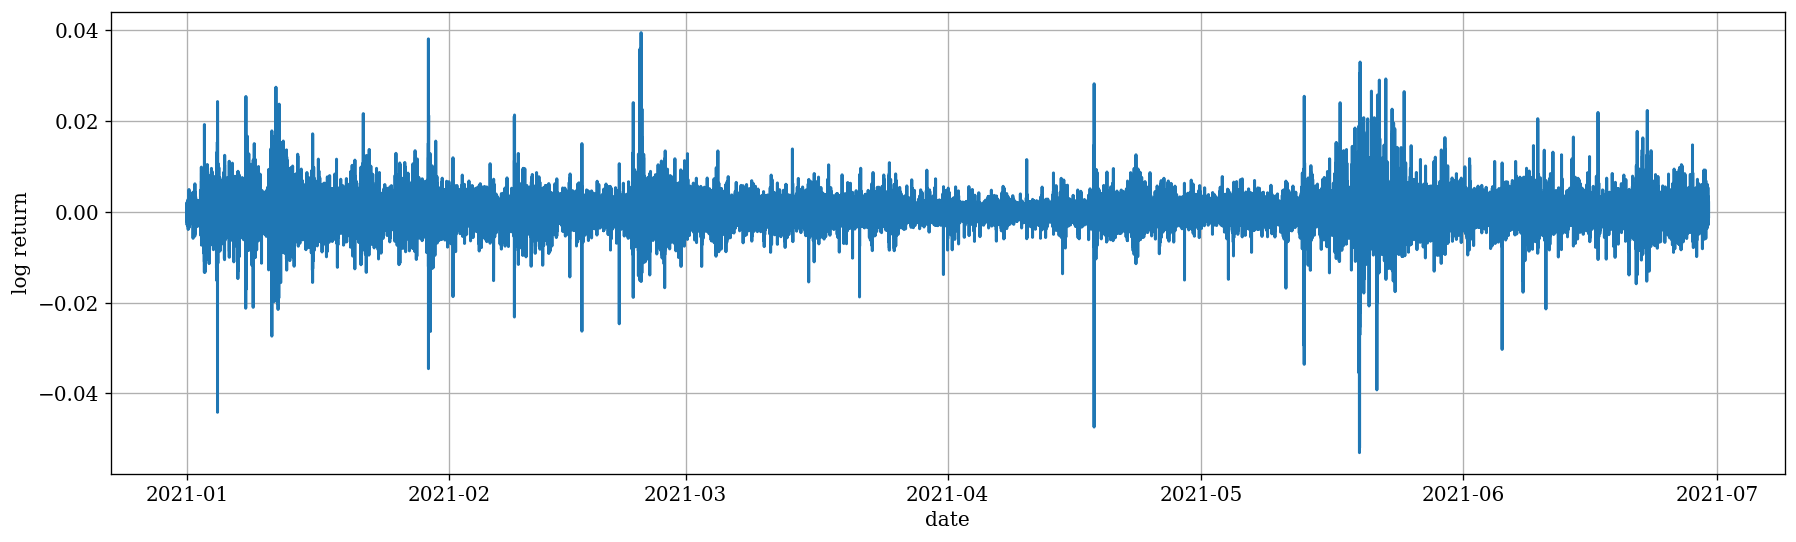

In [5]:
plt.figure(figsize = (18, 5))
plt.plot(returns)
plt.xlabel('date')
plt.ylabel('log return')
plt.grid(True)

In [11]:
L = np.array(returns).shape[0]

#train-test split. Train: first 90% times, Test: last 10% (assuming stationarity)

init_train = 0
final_train = init_test = int((9 * L) // 10) 


final_test = L-1


data_train = np.array(returns).reshape(1, -1)[:, init_train:final_train+1]
data_test = np.array(returns).reshape(1, -1)[:, init_test:final_test]

(-0.03, 0.03)

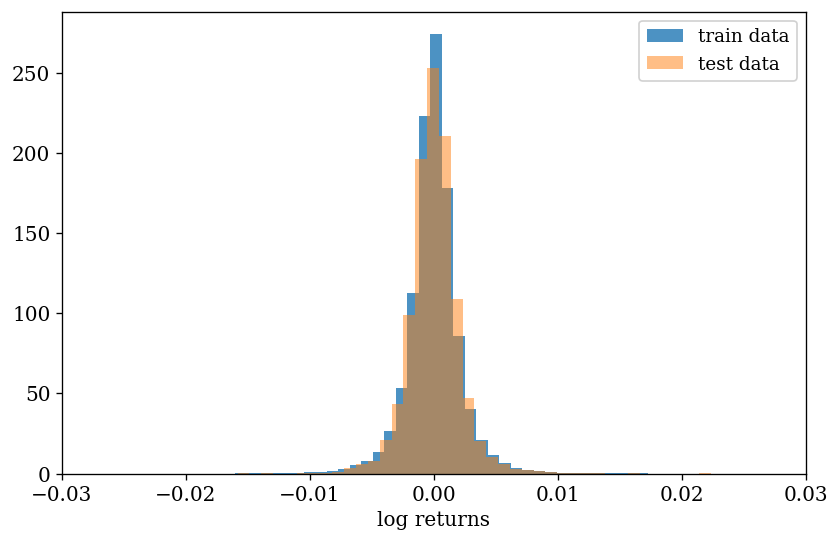

In [17]:
#plt.hist(returns, bins=100, density=True, label='full data')
plt.hist(data_train[0, :], bins=100, density=True, alpha=0.8, label ='train data')
plt.hist(data_test[0, :], bins=40, density=True, alpha=0.5, label ='test data')
plt.xlabel('log returns')
plt.legend()
plt.xlim(-0.03, 0.03)

In [18]:
from tqdm import tqdm

### Training Hidden Markov model with Student's emissions and three regimes

err = []
HMM_list = []
N_cycles = 10  # number of iterations to escape local minima
final_err = []

for i in tqdm(range(N_cycles)):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [0, np.random.uniform(0.0, 0.05), 20],  # state 0
    [0, np.random.uniform(0.0, 0.05), 5],  # state 1
    [0, np.random.uniform(0.0, 0.05), 20],
    ])
    
    emission = emission_model.Student_Emission(3, data_train, params, params_to_optimize=[True, True, True])
    HMM = hmm.Hmm(3, emission, pi, A=None, eps=1e-8)
    
    err.append(HMM.Baum_Welch(data_train, data_test=data_test, N_max=70))
    final_err.append(err[i][-1])
    
    HMM_list.append(HMM)

  0%|          | 0/10 [00:00<?, ?it/s]

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =      -3.127403  |  -ΔL/L = 100.000000% |  -logL_test = 3.211871%
Iteration    2  |  -logL =      -4.822058  |  -ΔL/L = 54.187301% |  -logL_test = 4.413255%
Iteration    3  |  -logL =      -4.778058  |  -ΔL/L = -0.912473% |  -logL_test = 4.436706%
Iteration    4  |  -logL =      -4.769284  |  -ΔL/L = -0.183644% |  -logL_test = 4.228046%
Iteration    5  |  -logL =      -4.807819  |  -ΔL/L = 0.807982% |  -logL_test = 4.413998%
Iteration    6  |  -logL =      -4.819603  |  -ΔL/L = 0.245112% |  -logL_test = 4.392383%
Iteration    7  |  -logL =      -4.823152  |  -ΔL/L = 0.073639% |  -logL_test = 4.398161%
Iteration    8  |  -logL =      -4.825770  |  -ΔL/L = 0.054282% |  -logL_test = 4.402964%
Iteration    9  |  -logL =      -4.82

 10%|█         | 1/10 [06:03<54:30, 363.44s/it]

Iteration   71  |  -logL =      -4.919276  |  -ΔL/L = 0.017645% |  -logL_test = 4.539478%
Learning Finished
############################################################################################################################################################################
############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =      -2.965407  |  -ΔL/L = 100.000000% |  -logL_test = 3.009299%
Iteration    2  |  -logL =      -4.813603  |  -ΔL/L = 62.325182% |  -logL_test = 4.425778%
Iteration    3  |  -logL =      -4.815232  |  -ΔL/L = 0.033847% |  -logL_test = 4.411958%
Iteration    4  |  -logL =      -4.843867  |  -ΔL/L = 0.594669% |  -logL_test = 4.446610%
Iteration    5  |  -logL =      -4.858591  |  -ΔL/L = 0.303975% |  -logL_test = 4.442075%
Iteration    6  |  -logL =  

 20%|██        | 2/10 [10:51<42:34, 319.36s/it]

...

Iteration   71  |  -logL =      -4.902347  |  -ΔL/L = 0.000003% |  -logL_test = 4.512292%
Learning Finished
############################################################################################################################################################################
############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =      -2.441968  |  -ΔL/L = 100.000000% |  -logL_test = 2.502305%
Iteration    2  |  -logL =      -4.814798  |  -ΔL/L = 97.168736% |  -logL_test = 4.423824%
Iteration    3  |  -logL =      -4.806053  |  -ΔL/L = -0.181630% |  -logL_test = 4.432986%
Iteration    4  |  -logL =      -4.807339  |  -ΔL/L = 0.026773% |  -logL_test = 4.432324%
Iteration    5  |  -logL =      -4.811332  |  -ΔL/L = 0.083047% |  -logL_test = 4.432744%
Iteration    6  |  -logL = 

 90%|█████████ | 9/10 [42:37<04:34, 274.93s/it]

Iteration   71  |  -logL =      -4.902948  |  -ΔL/L = 0.000265% |  -logL_test = 4.512344%
Learning Finished
############################################################################################################################################################################
############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =      -2.483433  |  -ΔL/L = 100.000000% |  -logL_test = 2.484356%
Iteration    2  |  -logL =      -4.815596  |  -ΔL/L = 93.908789% |  -logL_test = 4.423639%
Iteration    3  |  -logL =      -4.787786  |  -ΔL/L = -0.577493% |  -logL_test = 4.436293%
Iteration    4  |  -logL =      -4.822353  |  -ΔL/L = 0.721981% |  -logL_test = 4.384100%
Iteration    5  |  -logL =      -4.809872  |  -ΔL/L = -0.258825% |  -logL_test = 4.438922%
Iteration    6  |  -logL =

100%|██████████| 10/10 [47:25<00:00, 284.57s/it]

Iteration   71  |  -logL =      -4.924038  |  -ΔL/L = 0.000190% |  -logL_test = 4.548008%
Learning Finished
############################################################################################################################################################################


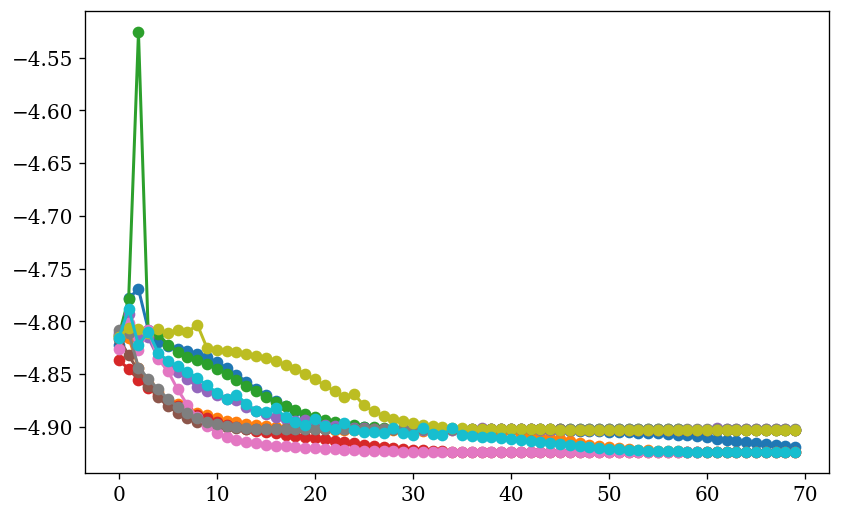

In [21]:
import matplotlib.pyplot as pltFalse

for i in range(N_cycles):
    
    plt.plot(err[i][1:], marker='o')

In [22]:
HMM = HMM_list[np.argmin(np.array(final_err))]

In [23]:
HMM.emission.params

array([[-1.34414366e-04,  3.48621055e-03,  4.50101070e+00],
       [ 1.05765764e-05,  9.15878538e-04,  7.24358252e+00],
       [ 9.56632539e-06,  1.72343390e-03,  7.71635733e+00]])

In [42]:
# saving the HMM to file

import pickle

with open('HMM_btc_2021.pkl', 'wb') as f:
    pickle.dump(HMM, f)


In [6]:
# no need to re run the training
import pickle

with open('HMM_btc_2021.pkl', 'rb') as f:
    HMM = pickle.load(f)

Text(0.5, 1.0, 'emission probability distributions (volatility regimes)')

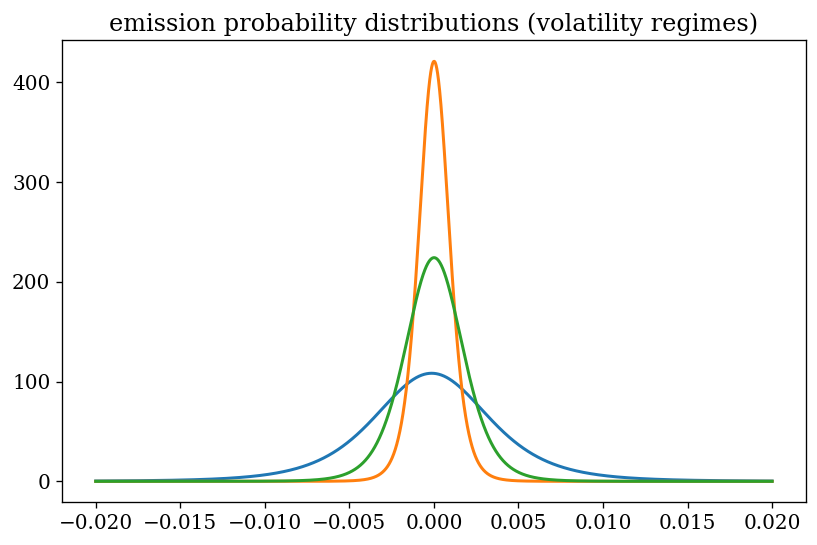

In [8]:
from utils import Student
x = np.linspace(-0.02, 0.02, 10000)
plt.plot(x, Student(x, *HMM.emission.params[0, :]))
plt.plot(x, Student(x, *HMM.emission.params[1, :]))
plt.plot(x, Student(x, *HMM.emission.params[2, :]))
plt.title('emission probability distributions (volatility regimes)')

In [16]:
print(HMM.emission.params)
print(HMM.A)

[[-1.34414366e-04  3.48621055e-03  4.50101070e+00]
 [ 1.05765764e-05  9.15878538e-04  7.24358252e+00]
 [ 9.56632539e-06  1.72343390e-03  7.71635733e+00]]
[[9.81124706e-01 2.93544137e-23 1.88752945e-02]
 [1.13679223e-04 9.88201066e-01 1.16852551e-02]
 [5.34021746e-03 1.02615250e-02 9.84398258e-01]]


In [13]:
# get the best sequence of hidden states given the model parameters from training
best_seq_train = HMM.Viterbi(data_train)

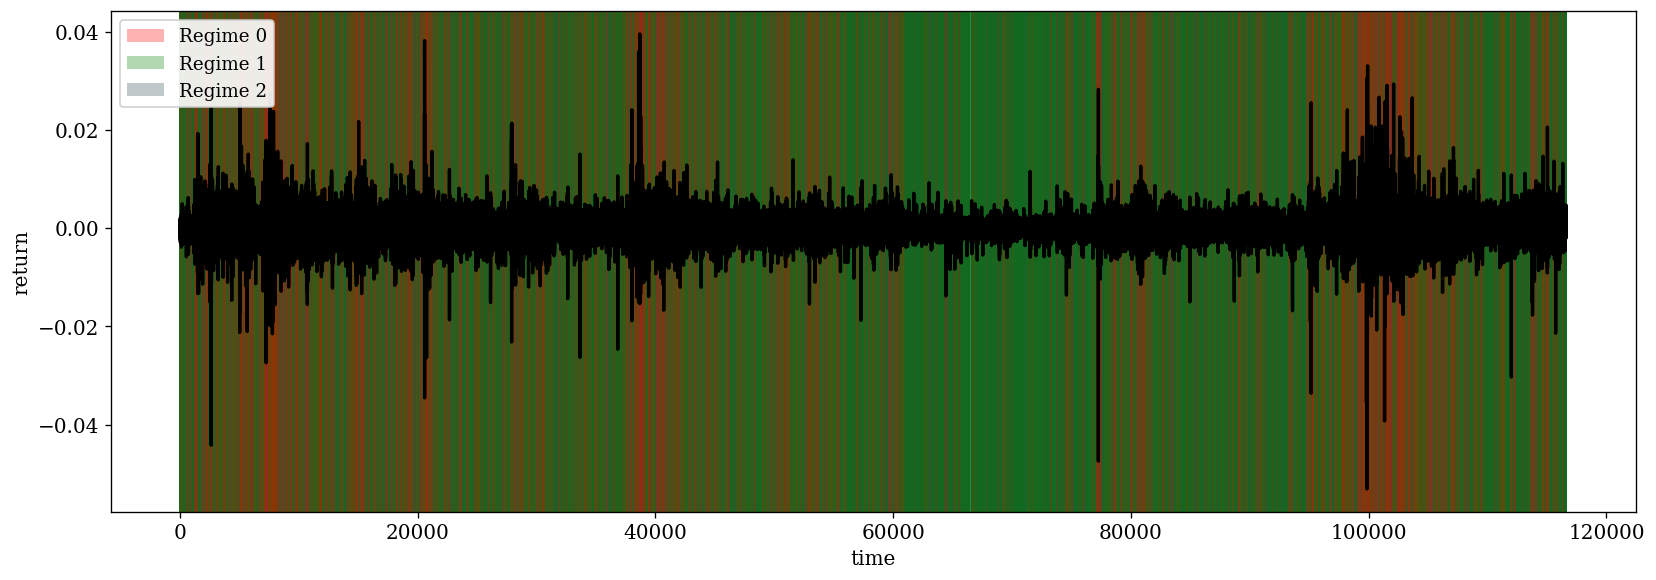

In [14]:
# plotting regimes

dates = [i for i in range(final_train - init_train +1)]

plot_regimes(dates[:], np.array(returns)[init_train:final_train+1], HMM.best_seqs[0, :] , n_states=3, colors=['red', 'green', 'darkslategrey'])

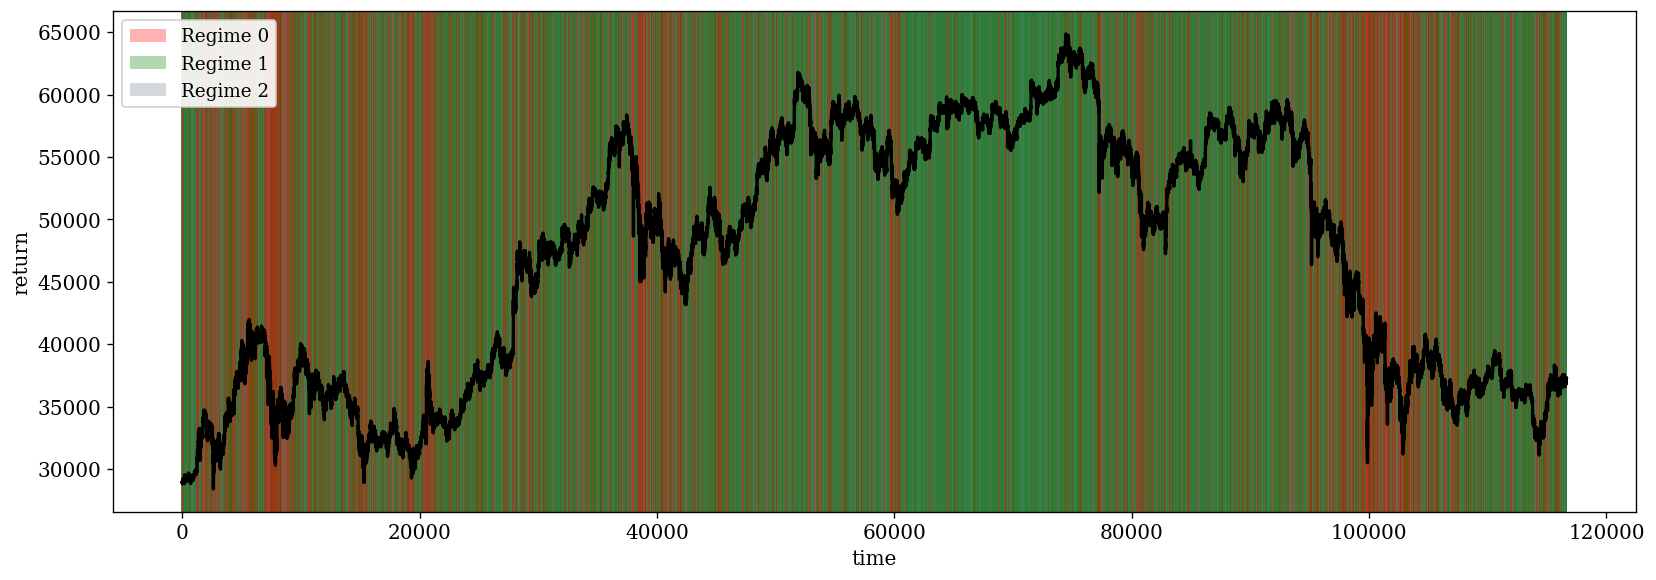

Text(0, 0.5, 'price')

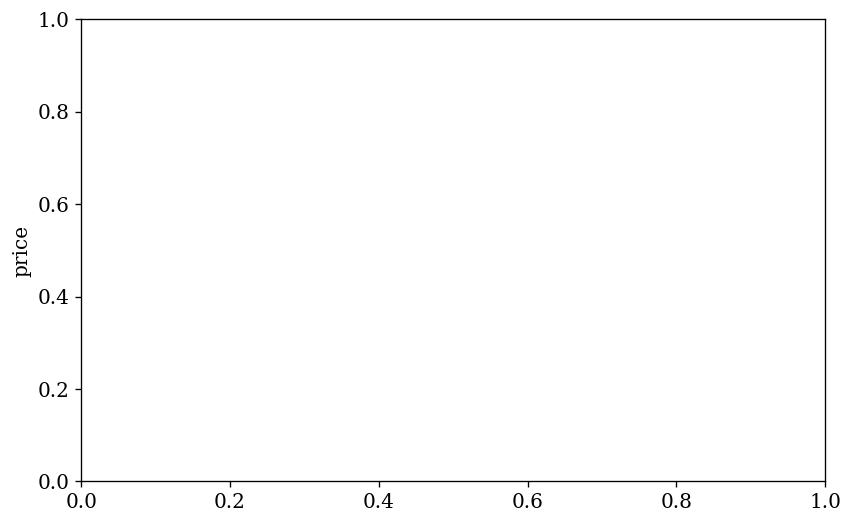

In [17]:
# plotting regimes and price 

dates = [i for i in range(final_train - init_train +1)]

plot_regimes(dates[:], np.array(two_freq_2021)[init_train:final_train+1], HMM.best_seqs[0, :] , n_states=3, colors=['red', 'green', 'slategrey'])
plt.ylabel('price')


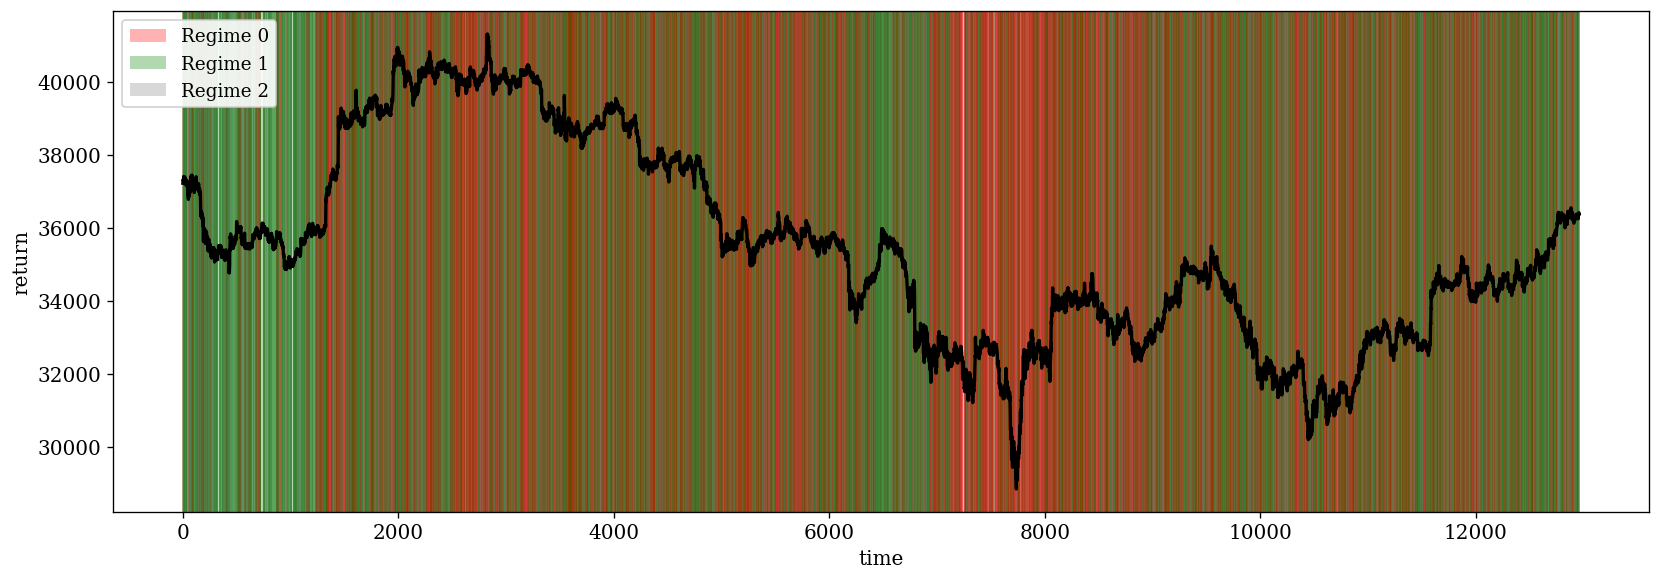

In [18]:
# test data 

HMM.Viterbi(data_test)
dates = [i for i in range(final_test - init_test +1)]


plot_regimes(dates[:], np.array(two_freq_2021)[init_test:final_test+1], HMM.best_seqs[0, :] , n_states=3, colors=['red', 'green', 'grey'])

In [ ]:
# comparing likelihoods with single fitted gaussian data

from utils import Student
def Gaussian(x, mu, sigma):

    return np.exp(-0.5*((x-mu)/sigma)**2)/(np.sqrt(2*np.pi*sigma**2))
mu = np.mean(data_train)
sigma = np.std(data_train)
x = np.linspace(-0.02, 0.02, 100000)
plt.hist(data_train)
plt.plot(x, Gaussian(x, mu, sigma))



KeyboardInterrupt: 